In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
%matplotlib inline

In [65]:
from sklearn.datasets import make_blobs

In [66]:
x,y=make_blobs(n_features=3,centers=3,n_samples=1000)

In [67]:
x

array([[-7.47883171,  0.06291916,  1.43925075],
       [-7.65934707, -0.68620941,  0.46560579],
       [-4.35473836,  6.67002279, -6.05768935],
       ...,
       [-5.3076018 ,  8.06658433, -3.58121598],
       [-4.39146302,  7.42873841, -5.12024506],
       [-7.77789479,  0.68976638,  0.48615993]])

In [68]:
y

array([0, 0, 2, 2, 1, 1, 0, 0, 0, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1, 2, 2, 1,
       0, 0, 0, 2, 0, 0, 2, 2, 1, 0, 2, 0, 1, 0, 1, 1, 1, 2, 0, 1, 2, 2,
       2, 2, 1, 2, 1, 0, 2, 0, 1, 1, 1, 1, 0, 0, 0, 2, 0, 0, 0, 1, 2, 2,
       1, 1, 0, 0, 0, 2, 2, 0, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 2, 1, 2, 0, 1, 2, 1, 1, 0, 2, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 2, 0, 0, 2, 1, 2, 1, 1, 0, 0, 0, 2, 0, 1, 1, 2, 0, 0, 2, 1,
       0, 0, 1, 2, 2, 2, 2, 0, 1, 1, 0, 2, 2, 2, 1, 0, 1, 2, 0, 0, 2, 2,
       0, 0, 2, 1, 1, 2, 2, 2, 1, 2, 0, 1, 1, 0, 1, 2, 1, 2, 1, 1, 2, 0,
       2, 2, 0, 2, 2, 0, 2, 2, 0, 1, 1, 0, 1, 2, 0, 2, 1, 2, 2, 1, 0, 2,
       2, 0, 0, 1, 0, 1, 2, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 1, 2, 1, 0, 1,
       1, 1, 0, 2, 1, 2, 0, 2, 2, 2, 1, 0, 1, 0, 2, 2, 0, 1, 1, 2, 2, 1,
       2, 2, 1, 1, 0, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       2, 2, 1, 2, 2, 0, 2, 2, 2, 0, 0, 0, 2, 1, 1, 0, 2, 2, 1, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 0, 0, 2,

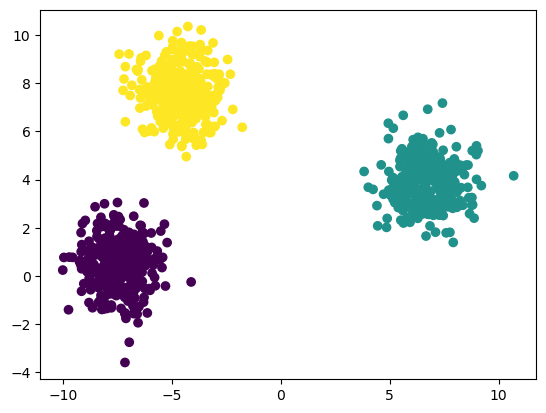

In [69]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [70]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.25)

In [71]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

In [72]:
x_train_scaled=scalar.fit_transform(x_train)
len(x_train_scaled)

750

In [73]:
x_test_scaled=scalar.transform(x_test)
len(x_test_scaled)

250

In [74]:
from sklearn.cluster import KMeans


In [75]:
wcss=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

c:\Users\ajayj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ajayj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ajayj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ajayj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [76]:
wcss

[1191.2880472075335,
 140.096770966726,
 123.70915553472891,
 119.51704539712853,
 97.80360554015056,
 82.77001617564775,
 77.82299272308663,
 70.09897303437467,
 71.55736309705574]

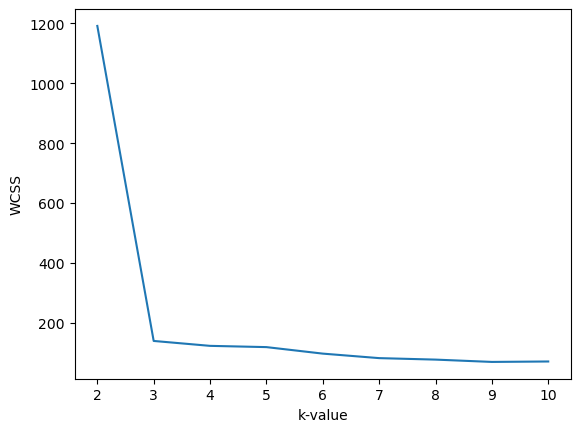

In [77]:
sns.lineplot(x=range(2,11),y=wcss)
plt.xlabel("k-value")
plt.ylabel("WCSS")
plt.show()

In [78]:
kmeans=KMeans(n_clusters=3)
kmeans.fit(x_train_scaled)

c:\Users\ajayj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


KMeans(n_clusters=3)

In [79]:
y_pred=kmeans.predict(x_test)

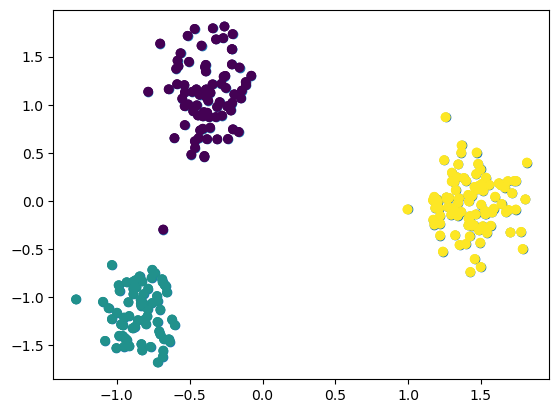

In [83]:
plt.scatter(x_test_scaled[:,0],x_test_scaled[:,1],c=y_pred)
plt.show()

In [84]:
!pip install kneed

In [89]:
from kneed import KneeLocator
KneeLocator(x=range(2,11),y=wcss,curve='convex',direction='decreasing').elbow


np.int64(3)